# Bayesian exploration from YAML

In [1]:
from xopt import Xopt

# set values if testing
import os

import warnings

warnings.filterwarnings("ignore")


SMOKE_TEST = os.environ.get("SMOKE_TEST")

YAML = """
generator:
    name: bayesian_exploration
    vocs:
        variables:
            x1: [0, 3.14159]
            x2: [0, 3.14159]
        objectives:
            y1: EXPLORE
        constraints:
            c1: [GREATER_THAN, 0]
            c2: [LESS_THAN, 0.5]
        constants: {a: dummy_constant}
evaluator:
    function: xopt.resources.test_functions.tnk.evaluate_TNK



"""

In [2]:
X = Xopt.from_yaml(YAML)

# for testing purposes only
if SMOKE_TEST:
    X.generator.numerical_optimizer.n_restarts = 1
    X.generator.n_monte_carlo_samples = 1

X


            Xopt
________________________________
Version: 3.0.1
Data size: 0
Config as YAML:
dump_file: null
evaluator:
  function: xopt.resources.test_functions.tnk.evaluate_TNK
  function_kwargs:
    raise_probability: 0
    random_sleep: 0
    sleep: 0
  max_workers: 1
  vectorized: false
generator:
  computation_time: null
  custom_objective: null
  fixed_features: null
  gp_constructor:
    covar_modules: {}
    custom_noise_prior: null
    mean_modules: {}
    name: standard
    train_config: null
    train_kwargs: null
    train_method: lbfgs
    train_model: true
    trainable_mean_keys: []
    transform_inputs: true
    use_cached_hyperparameters: false
    use_low_noise_prior: false
  max_travel_distances: null
  model: null
  n_candidates: 1
  n_interpolate_points: null
  n_monte_carlo_samples: 128
  name: bayesian_exploration
  numerical_optimizer:
    max_iter: 2000
    max_time: 5.0
    n_restarts: 20
    name: LBFGS
  returns_id: false
  supports_batch_generation: true

In [3]:
X.random_evaluate(5)

for i in range(5):
    print(f"step {i}")
    X.step()

step 0


step 1


step 2


step 3


step 4


In [4]:
print(X.data)

         x1        x2               a        y1        y2        c1        c2  \
0  2.840669  1.370388  dummy_constant  2.840669  1.370388  8.885871  6.236305   
1  2.159644  1.161221  dummy_constant  2.159644  1.161221  5.016447  3.191631   
2  0.536863  2.150980  dummy_constant  0.536863  2.150980  3.986595  2.727093   
3  1.145400  1.025355  dummy_constant  1.145400  1.025355  1.299880  0.692539   
4  0.789992  2.752934  dummy_constant  0.789992  2.752934  7.226610  5.159805   
5  0.040112  0.310129  dummy_constant  0.040112  0.310129 -0.855392  0.247548   
6  1.042917  0.663500  dummy_constant  1.042917  0.663500  0.621532  0.321491   
7  0.724060  0.994405  dummy_constant  0.724060  0.994405  0.593017  0.294639   
8  0.000000  1.299494  dummy_constant  0.000000  1.299494  0.588684  0.889190   
9  0.516449  0.893275  dummy_constant  0.516449  0.893275  0.115491  0.154936   

   xopt_runtime  xopt_error  
0      0.006085       False  
1      0.003107       False  
2      0.000270   

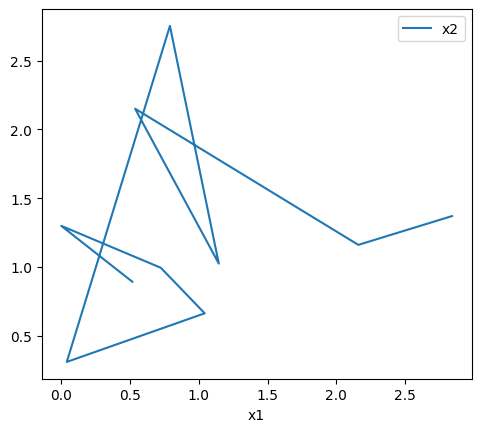

In [5]:
# plot results
ax = X.data.plot("x1", "x2")
ax.set_aspect("equal")

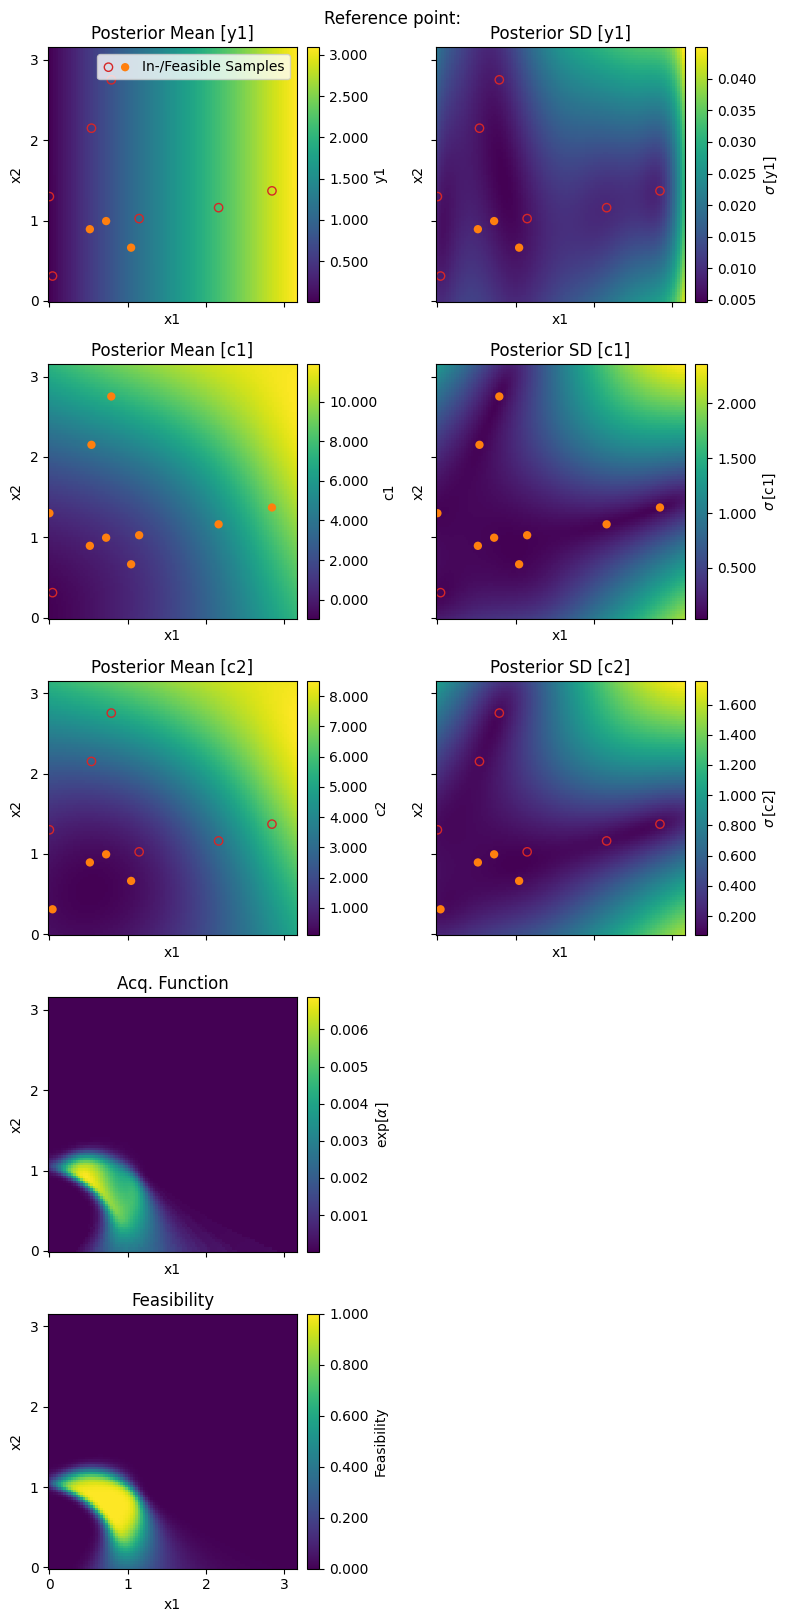

In [6]:
fig, ax = X.generator.visualize_model(show_feasibility=True, n_grid=100)